Today's topics:
* why repeated measurements need a "center" number and a "spread" number
* mean and median, by hand and with NumPy
* variance and standard deviation, by hand and with NumPy

> By the end of today you should be able to compute mean, median, variance, and standard deviation by hand and with NumPy

# Repeated measurements

<img src="https://upload.wikimedia.org/wikipedia/commons/b/bf/Rockwell_hardness_tester_001.jpg" alt="Rockwell hardness tester" height=250/>

(Three-quarter-ten, [Wikimedia Commons](https://commons.wikimedia.org/wiki/File:Rockwell_hardness_tester_001.jpg), [CC BY-SA 3.0](https://creativecommons.org/licenses/by-sa/3.0/))

20 hardness readings, same specimen.

*Why would they differ?* The indenter lands on different microstructural
neighborhoods. Surface preparation varies. The machine has finite repeatability.
In materials testing, spread is often signal, not just noise.

Two questions:
1. Where is the data centered?
2. How spread out is it?

# Warm-up: mean and median by eye

In [1]:
import numpy as np

warmup = np.array([2, 4, 4, 6, 9])
print(warmup)
print(f'mean: {np.mean(warmup)}')
print(f'median: {np.median(warmup)}')

[2 4 4 6 9]
mean: 5.0
median: 4.0


Sum = 25, N = 5 → mean 5. Sorted middle value → median 4. Mean ≠ median, even here.

# The dataset: 20 hardness readings

## Dataset: Repeated Rockwell Hardness (HRC) Readings

**Provenance:** these are synthetic teaching values, designed to resemble repeated
measurements from heat-treated steel. They are not records from a published
experiment.

`hardness` represents 20 Rockwell-C hardness readings at different points on the
*same* specimen. In principle a homogeneous specimen should give the same number
every time, but indentation tests have measurement noise (probe placement, local
microstructure, surface finish), so the simulated readings have a realistic spread.
One reading (index 19) is noticeably higher than the rest -- worth keeping an eye on
as we compare mean and median.

`furnace_A` and `furnace_B` represent 20 readings each from two simulated
heat-treatment batches. Both batches target the same hardness, while batch B was
constructed with substantially more variability. Use them to compare two batches
with (nearly) the same mean but very different spread.

In [2]:
import numpy as np

hardness = np.array([58.2, 57.9, 58.6, 57.5, 58.9, 58.1, 57.8, 58.4, 58.0, 57.6,
                      58.3, 58.7, 57.4, 58.2, 58.5, 57.9, 58.1, 58.8, 57.7, 63.9])

furnace_A = np.array([58.6, 58.5, 58.2, 58.5, 57.9, 57.4, 58.9, 58.4, 57.3, 57.7,
                       57.9, 58.3, 58.8, 58.3, 58.0, 58.4, 58.1, 58.3, 57.9, 57.7])
furnace_B = np.array([58.3, 57.4, 59.5, 56.2, 60.4, 58.0, 57.1, 58.9, 57.7, 56.5,
                       58.6, 59.8, 55.9, 58.3, 59.2, 57.4, 58.0, 60.1, 56.8, 59.5])

print(f'{len(hardness)} hardness readings, units HRC')
print(hardness)

20 hardness readings, units HRC
[58.2 57.9 58.6 57.5 58.9 58.1 57.8 58.4 58.  57.6 58.3 58.7 57.4 58.2
 58.5 57.9 58.1 58.8 57.7 63.9]


In [3]:
print(hardness)
print(len(hardness))

[58.2 57.9 58.6 57.5 58.9 58.1 57.8 58.4 58.  57.6 58.3 58.7 57.4 58.2
 58.5 57.9 58.1 58.8 57.7 63.9]
20




Most values cluster high-57s to high-58s. Last reading, 63.9, stands out.
*Surface artifact (edge, dirty surface) or real heterogeneity (different microstructure)?*
Statistics flag it. Deciding the cause requires materials knowledge.

# Mean: the balance point

*What does "mean" actually do, mathematically?*

$$\bar{x} = \frac{1}{N}\sum_{i=1}^N x_i$$

In [4]:
total = np.sum(hardness)
N = len(hardness)
mean_by_hand = total / N
print(f'sum: {total}')
print(f'N:   {N}')
print(f'mean (by hand): {mean_by_hand:.4f}')

sum: 1168.5000000000002
N:   20
mean (by hand): 58.4250


[`np.mean`](https://numpy.org/doc/stable/reference/generated/numpy.mean.html). same formula, built in:

In [5]:
print(f'mean (np.mean): {np.mean(hardness):.4f}')

mean (np.mean): 58.4250


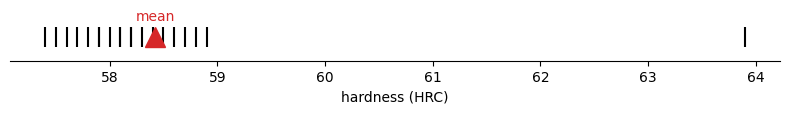

In [6]:
#@title Visualization: mean as balance point (click ▶ to run) { display-mode: "form" }
import matplotlib.pyplot as plt

_mu = np.mean(hardness)
fig, ax = plt.subplots(figsize=(8, 1.2))
ax.scatter(hardness, [0]*len(hardness), marker='|', s=200, color='black', zorder=2)
ax.plot(_mu, 0, marker='^', markersize=14, color='C3', zorder=3, clip_on=False)
ax.annotate('mean', (_mu, 0), textcoords='offset points', xytext=(0, 12),
            ha='center', fontsize=10, color='C3')
ax.set_yticks([])
ax.set_xlabel('hardness (HRC)')
ax.spines[['top', 'right', 'left']].set_visible(False)
plt.tight_layout()
plt.show()

## Is the mean sensitive to unusual values?

In [7]:
hardness_inflated = hardness.copy()  # .copy() makes an independent copy -- without it, changing one would change both
hardness_inflated[-1] = 78.5
print(hardness_inflated)

[58.2 57.9 58.6 57.5 58.9 58.1 57.8 58.4 58.  57.6 58.3 58.7 57.4 58.2
 58.5 57.9 58.1 58.8 57.7 78.5]


One value out of 20, and the mean moves. A single heavy weight shifts the balance point.

# Median: the middle value

Sort first:

In [8]:
sorted_hardness = np.sort(hardness)
print(sorted_hardness)

[57.4 57.5 57.6 57.7 57.8 57.9 57.9 58.  58.1 58.1 58.2 58.2 58.3 58.4
 58.5 58.6 58.7 58.8 58.9 63.9]


N = 20 (even) → no single middle element. Average positions 9 and 10:

In [9]:
lower_mid = sorted_hardness[9]
upper_mid = sorted_hardness[10]
median_by_hand = (lower_mid + upper_mid) / 2
print(f'lower middle value: {lower_mid}')
print(f'upper middle value: {upper_mid}')
print(f'median (by hand): {median_by_hand:.4f}')

lower middle value: 58.1
upper middle value: 58.2
median (by hand): 58.1500


Odd N → single middle element, no averaging.

[`np.median`](https://numpy.org/doc/stable/reference/generated/numpy.median.html):

In [10]:
print(f'median (np.median): {np.median(hardness):.4f}')

median (np.median): 58.1500


## Does the median react the same way?

In [11]:
print(f'original -- mean: {np.mean(hardness):.4f}, median: {np.median(hardness):.4f}')
print(f'inflated -- mean: {np.mean(hardness_inflated):.4f}, median: {np.median(hardness_inflated):.4f}')

original -- mean: 58.4250, median: 58.1500
inflated -- mean: 59.1550, median: 58.1500


Mean jumped; median barely moved. **Robustness**: median only cares about rank, not magnitude.

Even on the original data, mean > median: the 63.9 reading already pulling it up.

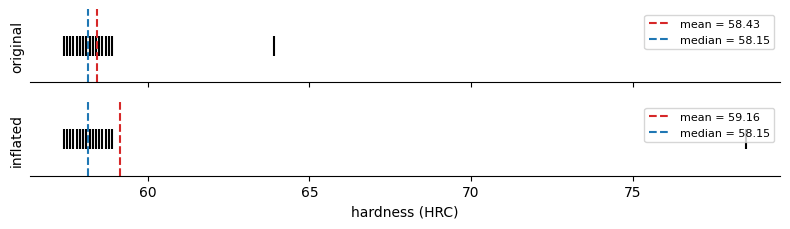

In [12]:
#@title Visualization: mean vs median with outlier (click ▶ to run) { display-mode: "form" }
fig, axes = plt.subplots(2, 1, figsize=(8, 2.4), sharex=True)
for ax, data, label in zip(axes, [hardness, hardness_inflated], ['original', 'inflated']):
    ax.scatter(data, [0]*len(data), marker='|', s=200, color='black', zorder=2)
    ax.axvline(np.mean(data), color='C3', linestyle='--', label=f'mean = {np.mean(data):.2f}')
    ax.axvline(np.median(data), color='C0', linestyle='--', label=f'median = {np.median(data):.2f}')
    ax.set_ylabel(label, fontsize=10)
    ax.set_yticks([])
    ax.legend(fontsize=8, loc='upper right')
    ax.spines[['top', 'right', 'left']].set_visible(False)
axes[1].set_xlabel('hardness (HRC)')
plt.tight_layout()
plt.show()

### [Check your understanding]

Using `hardness`:
* Make a fresh copy, set index 0 to `40.0`.
* Compute mean and median of both original and modified.
* Which statistic moved more? Does that match a single low outlier?

# Mode: the most common value

`[0, 1, 2, 3, 3]` → mode is 3.

In [13]:
mode_example = np.array([0, 1, 2, 3, 3])
print(mode_example)

[0 1 2 3 3]


Two of the five values are 3, that's the mode. No `np.mode` (`scipy.stats.mode` exists, out of scope). Rarely useful for continuous data like `hardness`. values are typically all unique.

# Variance: average distance from the mean

*How far, on average, is each reading from the mean?*

Build the **deviation** array:

In [14]:
mu = np.mean(hardness)
deviations = hardness - mu
print(deviations)

[-0.225 -0.525  0.175 -0.925  0.475 -0.325 -0.625 -0.025 -0.425 -0.825
 -0.125  0.275 -1.025 -0.225  0.075 -0.525 -0.325  0.375 -0.725  5.475]


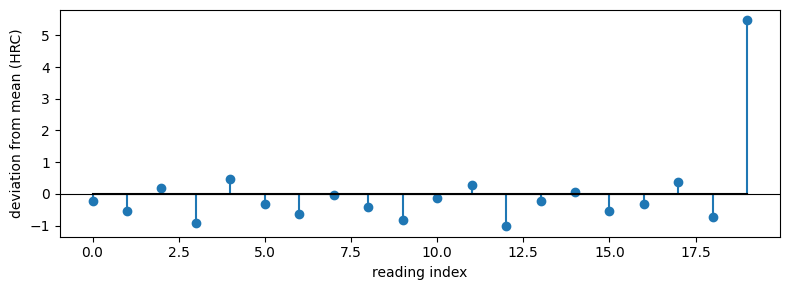

In [15]:
#@title Visualization: deviations from the mean (click ▶ to run) { display-mode: "form" }
fig, ax = plt.subplots(figsize=(8, 3))
ax.stem(range(len(deviations)), deviations, basefmt='k-', linefmt='C0-', markerfmt='C0o',
        label='deviation')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('reading index')
ax.set_ylabel('deviation from mean (HRC)')
plt.tight_layout()
plt.show()

In [16]:
print(f'mean deviation: {np.mean(deviations):.6f}')

mean deviation: -0.000000


Zero, always. Positive and negative deviations cancel by definition of the balance point. Average deviation can never measure spread.

Fix: square first.

$$\sigma^2 = \frac{1}{N}\sum_{i=1}^N (x_i - \bar{x})^2$$

In [17]:
squared_deviations = deviations ** 2
print(squared_deviations)

variance_by_hand = np.sum(squared_deviations) / N
print(f'variance (by hand): {variance_by_hand:.4f}')

[5.0625000e-02 2.7562500e-01 3.0625000e-02 8.5562500e-01 2.2562500e-01
 1.0562500e-01 3.9062500e-01 6.2500000e-04 1.8062500e-01 6.8062500e-01
 1.5625000e-02 7.5625000e-02 1.0506250e+00 5.0625000e-02 5.6250000e-03
 2.7562500e-01 1.0562500e-01 1.4062500e-01 5.2562500e-01 2.9975625e+01]
variance (by hand): 1.7509


[`np.var`](https://numpy.org/doc/stable/reference/generated/numpy.var.html):

In [18]:
print(f'variance (np.var): {np.var(hardness):.4f}')

variance (np.var): 1.7509


> **Note:** NumPy defaults to dividing by N (population variance). Your stats
> textbook may divide by N-1 (sample variance, Bessel's correction).
> Use `np.var(data, ddof=1)` for that.

ddof=0: these 20 readings are the whole story (describing this specimen).
ddof=1: these 20 readings sample a larger process (estimating batch variability).
The scientific question determines which.

Units got squared too. HRC² isn't on any spec sheet.

# Standard deviation: back to original units

$$\sigma = \sqrt{\sigma^2} = \sqrt{\frac{1}{N}\sum_{i=1}^N (x_i - \bar{x})^2}$$

In [19]:
std_by_hand = np.sqrt(variance_by_hand)
print(f'standard deviation (by hand): {std_by_hand:.4f}')

standard deviation (by hand): 1.3232


[`np.std`](https://numpy.org/doc/stable/reference/generated/numpy.std.html):

In [20]:
print(f'standard deviation (np.std): {np.std(hardness):.4f}')

standard deviation (np.std): 1.3232


"Mean ± one standard deviation", a typical range:

In [21]:
mu = np.mean(hardness)
sigma = np.std(hardness)
print(f'typical range: {mu - sigma:.2f} to {mu + sigma:.2f} HRC')

typical range: 57.10 to 59.75 HRC


> **Read more:** [PDSH -- Aggregations: Min, Max, and Everything In Between](https://jakevdp.github.io/PythonDataScienceHandbook/02.04-computation-on-arrays-aggregates.html)

### [Check your understanding]

* Spec is ±1 HRC of target: which furnace would you trust, and why?

## Hands-on: reverse-engineer the cert sheet

A supplier's certificate of analysis reports summary statistics for a batch of
10 parts, but not the individual measurements. Build an array of 10 numbers that
matches each target as closely as you can.

| round | target |
|---|---|
| 1 | mean = 58.0, all 10 values between 55 and 61 |
| 2 | mean = 58.0, median = 57.0 |
| 3 | mean = 58.0, standard deviation as large as possible, all 10 values between 40 and 76 |

Round 1: build a 10-value `np.array` with mean 58.0. Print the mean to check.

Round 2: build a different 10-value array with mean 58.0 and median 57.0. This
needs the values arranged so the middle two (sorted) average to 57 while the full
set averages to 58.

Round 3: build a 10-value array with mean 58.0 and the largest standard deviation
you can manage, keeping every value between 40 and 76. Print the mean and
standard deviation to check.

## Same mean, very different spread

Two furnaces, same target hardness:

In [22]:
print(f'furnace A -- mean: {np.mean(furnace_A):.2f}, std: {np.std(furnace_A):.4f}')
print(f'furnace B -- mean: {np.mean(furnace_B):.2f}, std: {np.std(furnace_B):.4f}')

furnace A -- mean: 58.16, std: 0.4201
furnace B -- mean: 58.18, std: 1.2848


Means nearly identical; furnace B's std is ~3x larger. Mean alone would say "identical."



Spec ±1 HRC: furnace A comfortably inside on nearly every part; furnace B routinely fails, even though its mean looks fine.

Furnace A has the smaller standard deviation, so its readings cluster more tightly around the target.

## Preview: plotting the spread

The code below is for visualization only. Don't worry about the plotting
commands yet.

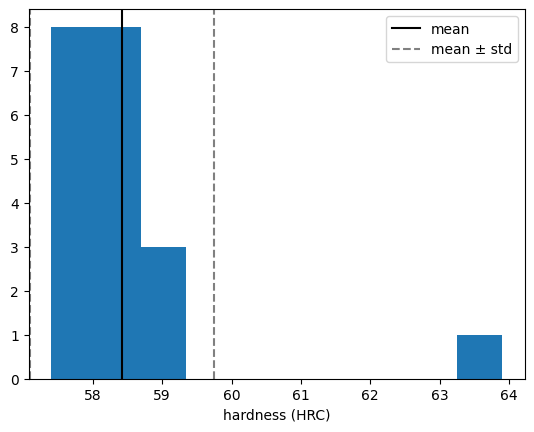

In [23]:
#@title Visualization: hardness histogram with mean ± std (click ▶ to run) { display-mode: "form" }
import matplotlib.pyplot as plt

plt.hist(hardness, bins=10)
plt.axvline(mu, color='black', label='mean')
plt.axvline(mu - sigma, color='gray', linestyle='--', label='mean ± std')
plt.axvline(mu + sigma, color='gray', linestyle='--')
plt.xlabel('hardness (HRC)')
plt.legend()
plt.show()